# Preprocessing and quality control

1) **Quality control**
    * mt genes, soup, doublets
2) **Normalization**
    * log, scran, Peasrson, SCtransform
3) **Feature selection**
    * highly deviant genes 

In [ ]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.sparse import csr_matrix

As a next step we initialize an AnnData object with random poisson distributed data. It is an unwritten rule to name the primary AnnData object of the analysis adata.



In [ ]:
counts = csr_matrix(np.random.poisson(1, size=(100, 2000)), dtype=np.float32)
adata = ad.AnnData(counts)
adata

The obtained AnnData object has 100 observations and 2000 variables. This would correspond to 100 cells with 2000 genes. The initial data we passed are accessible as a sparse matrix using adata.X.


In [ ]:
adata.X


In [ ]:
adata.obs_names = [f"Cell_{i:d}" for i in range(adata.n_obs)]
adata.var_names = [f"Gene_{i:d}" for i in range(adata.n_vars)]
print(adata.obs_names[:10])

The core of our AnnData object is now in place. As a next step we add metadata at both, the observational and variable levels. Remember, we store such annotations in the `.obs` and `.var` slots of the AnnData object for cell and gene annotations respectively.



In [ ]:
ct = np.random.choice(["B", "T", "Monocyte"], size=(adata.n_obs,))
adata.obs["cell_type"] = pd.Categorical(ct)  # Categoricals are preferred for efficiency
adata.obs

If we examine the representation of the AnnData object again now, we will notice that it got updated as well with the cell_type information in obs.



In [ ]:
adata


More at [https://www.sc-best-practices.org/introduction/analysis_tools.html]

# Real world examples

# 1
In the following cells we will shortly demonstrate the workflow of an analysis with scanpy. We explicitly do not conduct a full analysis because the specific analysis steps are covered in the corresponding chapters.

The dataset of choice is a dataset of 2700 peripheral blood mononuclear cells of a healthy donor which were sequenced on the Illumina NextSeq 500.

In [ ]:
import scanpy as sc


In [ ]:
sc.settings.set_figure_params(dpi=80, facecolor="white")
sc.logging.print_header()


In [ ]:
adata = sc.datasets.pbmc3k()


In [ ]:
print(adata)
adata.var


In [ ]:
sc.pl.highest_expr_genes(adata, n_top=30)
#Apparently, MALAT1 is the most expressed gene which is frequently detected in poly-A captured scRNA-Seq data,
#independent of protocol. This gene has been shown to have an inverse correlation with cell health. 
#Especially dead/dying cells have a higher expression of MALAT1.

We now filter cells with less than 200 detected genes and genes which were found in less than 3 cells for a rough quality threshold

In [ ]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [ ]:
adata

A common step in single-cell RNA-Seq analysis is dimensionality reduction with for example principal component analysis (PCA) to unveil the main axes of variation. This also denoises the data. scanpy offers PCA as a preprocessing or tools function. These are equivalent. Here, we use the version in tools for no particular reason.



In [ ]:
sc.tl.pca(adata, svd_solver="arpack")

In [ ]:
sc.pl.pca(adata, color="MALAT1")


# 2
We use a 10x Multiome data set generated for a single cell data integration challenge at the NeurIPS conference 2021 [Luecken et al., 2021]. This dataset captures single-cell multiomics data from bone marrow mononuclear cells of 12 healthy human donors measured at four different sites to obtain nested batch effects. In this tutorial, we will use one batch of the aforementioned dataset, sample 4 of donor 8, to showcase the best practices for scRNA-seq data preprocessing.



In [ ]:
import numpy as np
import scanpy as sc
import seaborn as sns
from scipy.stats import median_abs_deviation

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

In [ ]:
adata = sc.read_10x_h5(
    filename="filtered_feature_bc_matrix.h5",
    backup_url="https://figshare.com/ndownloader/files/39546196",
)
adata

In [ ]:
adata.var

In [ ]:
adata.var_names_make_unique()
adata.var_names

In [ ]:
adata.var_names[adata.var_names.str.startswith("RPS")]

In QC, the first step is to calculate the QC covariates or metric. We compute these using the scanpy function sc.pp.calculate_qc_metrics, which can also calculate the proportions of counts for specific gene populations. **We therefore define mitochondrial, ribosomal and hemoglobin genes**. It is important to note that mitochondrial counts are annotated either with the prefix “mt-” or “MT-’’ depending on the species considered in the dataset. As mentioned, the dataset used in this notebook is human bone marrow, so mitochondrial counts are annotated with the prefix “MT-”. For mouse datasets, the prefix is usually lower case, so “mt-“.

In [ ]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]"))

In [ ]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata

As we can see, the function added a couple of additional columns to .var and .obs. We want to highlight a few of them here, more information on the different metrics can be found in the scanpy documentation:

* `n_genes_by_counts` in `.obs` is the number of genes with positive counts in a cell,
* `total_counts` is the total number of counts for a cell, this might also be known as library size, and
* `pct_counts_mt` is the proportion of total counts for a cell which are mitochondrial.

We now plot the three QC covariates `n_genes_by_counts`, `total_counts` and `pct_counts_mt` per sample to assess how well the respective cells were captured.



In [ ]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [ ]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

The plots indicate that some reads have a relatively high percentage of mitochondrial counts which are often associated with cell degradation. But since number of counts per cell is sufficiently high and percentage of mitochondrial reads is for most cells below 20% we can still process the data. Based on these plots, one could now also define manual thresholds for filtering cells. Instead, we will show QC with automatic thresholding and filtering based on MAD.

First, we define a function that takes a metric, i.e. a column in `.obs` and the number of MADs (`nmad`) that is still permissive within the filtering strategy.



In [ ]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [ ]:
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)
adata.obs.outlier.value_counts()

pct_counts_Mt is filtered with 3 MADs. Additionally, cells with a percentage of mitochondrial counts exceeding 8 % are filtered out.



In [ ]:
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 8
)
adata.obs.mt_outlier.value_counts()

In [ ]:
adata.obs["mt_outlier"] 

In [ ]:
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

In [ ]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")


# Soup removal

In [ ]:
import anndata2ri
import logging

import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro

In [ ]:
rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

In [ ]:
%%R
#install.packages("SoupX")
library(SoupX)

SoupX can be run without clustering information, however as Young and Behjati[Young and Behjati, 2020] note that the results are better if a basic clustering is provided. SoupX can be used with the default clustering produced by cellranger or by manually defining clusters. We will showcase the latter in this notebook as the results from SoupX are not strongly sensitive to the clustering used.

We now create a copy of our AnnData object, normalize it, reduce its dimensionality and compute default Leiden clusters on the processed copy. A subsequent chapter introduces clustering in more detail. For now we just need to know that Leiden clustering gives us partitions (communities) of cells in our dataset. We save the obtained clusters as soupx_groups and delete the copy of the AnnData object to save some memory in our notebook.

Firstly, we generate a copy of our AnnData object, normalize and log1p transform it. We use simply shifted logarithm normalization at this point. More information on different normalization techniques can be found in the normalization chapter

In [ ]:
adata_pp = adata.copy()
sc.pp.normalize_per_cell(adata_pp)
sc.pp.log1p(adata_pp)

Next, we compute the principle components of the data to obtain a lower dimentional representation. This representation is then used to generate a neighbourhood graph of the data and run leiden clustering on the KNN-graph. We add the clusters as soupx_groups to .obs and save them as a vector.

In [ ]:
sc.pp.pca(adata_pp)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(adata_pp, key_added="soupx_groups")

# Preprocess variables for SoupX
soupx_groups = adata_pp.obs["soupx_groups"]

In [ ]:
soupx_groups

In [ ]:
sc.tl.pca(adata_pp, svd_solver='arpack')

In [ ]:
sc.pl.pca(adata_pp, color='MALAT1')


In [ ]:
del adata_pp

Next, we save the cell names, gene names and the data matrix of the filtered cellranger output. SoupX required a matrix of shape features x barcodes, so we have to transpose .X.

In [ ]:
cells = adata.obs_names
genes = adata.var_names
data = adata.X.T

SoupX additionally required the raw gene by cells matrix which is typically called raw_feature_bc_matrix.h5 in the cellranger output. We load this similarly as before the filtered_feature_bc_matrix.h5 with scanpy and run .var_names_make_unique() on the object and transpose the respective .X.

In [ ]:
adata_raw = sc.read_10x_h5(
    filename="raw_feature_bc_matrix.h5",
    backup_url="https://figshare.com/ndownloader/files/39546217",
)
adata_raw.var_names_make_unique()
data_tod = adata_raw.X.T

In [ ]:
del adata_raw


In [ ]:
data_tod

We have now everything in place to run SoupX. The inputs are the filtered cellranger matrix of shape barcodes x cells, the raw table of droplets from cellranger of shape barcodes x droplets, the gene and cell names and the clusters obtained by simple leiden clustering. The output will be the corrected count matrix.

We first construct a so called `SoupChannel` from the table of droplets and the table of cells. Next, we add metadata to the SoupChannel object which can be any metadata in the form of a data.frame. We add here

In [ ]:
%%R -i data -i data_tod -i genes -i cells -i soupx_groups -o out 

# specify row and column names of data
rownames(data) = genes
colnames(data) = cells
# ensure correct sparse format for table of counts and table of droplets
data <- as(data, "sparseMatrix")
data_tod <- as(data_tod, "sparseMatrix")

# Generate SoupChannel Object for SoupX 
sc = SoupChannel(data_tod, data, calcSoupProfile = FALSE)

# Add extra meta data to the SoupChannel object
soupProf = data.frame(row.names = rownames(data), est = rowSums(data)/sum(data), counts = rowSums(data))
sc = setSoupProfile(sc, soupProf)
# Set cluster information in SoupChannel
sc = setClusters(sc, soupx_groups)

# Estimate contamination fraction
sc  = autoEstCont(sc, doPlot=FALSE)
# Infer corrected table of counts and rount to integer
out = adjustCounts(sc, roundToInt = TRUE)

In [ ]:
out

SoupX successfully inferred corrected counts, which we can now store as an additional layer. In all following analysis steps, we would like to use the SoupX corrected count matrix, so we overwrite .X with the soupX corrected matrix.

In [ ]:
adata.layers["counts"] = adata.X
adata.layers["soupX_counts"] = out.T
adata.X = adata.layers["soupX_counts"]

In [ ]:
print(f"Total number of genes: {adata.n_vars}")

# Min 20 cells - filters out 0 count genes
sc.pp.filter_genes(adata, min_cells=20)
print(f"Number of genes after cell filter: {adata.n_vars}")

# Doublets

In [ ]:
%%R
library(Seurat)
#if (!require("BiocManager", quietly = TRUE))
#    install.packages("BiocManager")

#BiocManager::install("scater")
library(scater)
#BiocManager::install("scDblFinder")

library(scDblFinder)
library(BiocParallel)

We can now launch the doublet detection by using data_mat as input to scDblFinder within a SingleCellExperiment. scBblFinder adds several columns to the colData of sce. Three of them might be interesting for the analysis:

* sce$scDblFinder.score: the final doublet score (the higher the more likely that the cell is a doublet)

* sce$scDblFinder.ratio : the ratio of artificial doublets in the cell’s neighborhood

* sce$scDblFinder.class : the classification (doublet or singlet)

We will only output the class argument and store it in the AnnData object in `.obs`. The other arguments can be added to the AnnData object similarly.

In [ ]:
data_mat = adata.X.T


In [ ]:
%%R -i data_mat -o doublet_score -o doublet_class

set.seed(123)
sce = scDblFinder(
    SingleCellExperiment(
        list(counts=data_mat),
    ) 
)
doublet_score = sce$scDblFinder.score
doublet_class = sce$scDblFinder.class

scDblFinder outputs a class with the classification Singlet (1) and Doublet (2). We add this to our AnnData object in `.obs`.

In [ ]:
adata.obs["scDblFinder_score"] = doublet_score
adata.obs["scDblFinder_class"] = doublet_class
adata.obs.scDblFinder_class.value_counts()


During downstream clustering it might be useful to reassess quality control and the chosen parameters to potentially filter out more or less cells. We can now save the dataset and continue with the normalization chapter.



In [ ]:
adata.write("s4d8_quality_control.h5ad")


In [ ]:
adata.X

# Normalization

In [ ]:
adata = sc.read(
    filename="s4d8_quality_control.h5ad")

In [ ]:

import seaborn as sns
from matplotlib import pyplot as plt

from scipy.sparse import issparse

In [ ]:
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)


## shifted logarithm

In [ ]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

##  Scran’s pooling-based size factor estimation method

 Scran follows the same principles as the shifted logarithm ; The only difference now is that Scran leverages a deconvolution approach to estimate the size factors based on a linear regression over genes for pools of cells. This approach aims to better account for differences in count depths across all cells present in the dataset.

 Cells are partitioned into pools and Scran estimates pool-based size factors using a linear regression over genes. Scran was extensively tested for batch correction tasks and can be easily called with the respective R package.

In [ ]:
from scipy.sparse import csr_matrix, issparse


In [ ]:
%%R
library(scran)
library(BiocParallel)

scran requires a coarse clustering input to improve size factor esimation performance. In this tutorial, we use a simple preprocessing approach and cluster the data at a low resolution to get an input for the size factor estimation. The basic preprocessing includes assuming all size factors are equal (library size normalization to counts per million - CPM) and log-transforming the count data.

In [ ]:
# Preliminary clustering for differentiated normalisation
adata_pp = adata.copy()
sc.pp.normalize_total(adata_pp)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, n_comps=15)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(adata_pp, key_added="groups")

We now add data_mat and our computed groups into our R environment.



In [ ]:
data_mat = adata_pp.X.T
# convert to CSC if possible. See https://github.com/MarioniLab/scran/issues/70
if issparse(data_mat):
    if data_mat.nnz > 2**31 - 1:
        data_mat = data_mat.tocoo()
    else:
        data_mat = data_mat.tocsc()
ro.globalenv["data_mat"] = data_mat
ro.globalenv["input_groups"] = adata_pp.obs["groups"]

In [ ]:
del adata_pp


We now compute the size factors based on the groups of cells we calculated before.


In [ ]:
%%R -o size_factors

size_factors = sizeFactors(
    computeSumFactors(
        SingleCellExperiment(
            list(counts=data_mat)), 
            clusters = input_groups,
            min.mean = 0.1,
            BPPARAM = MulticoreParam()
    )
)


In [ ]:
adata.obs["size_factors"] = size_factors
scran = adata.X / adata.obs["size_factors"].values[:, None]
adata.layers["scran_normalization"] = csr_matrix(sc.pp.log1p(scran))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(
    adata.layers["scran_normalization"].sum(1), bins=100, kde=False, ax=axes[1]
)
axes[1].set_title("log1p with Scran estimated size factors")
plt.show()

## Analytic Pearson residuals

The third normalization technique we are introducing in this chapter is the analytic approximation of Pearson residuals. This normalization technique was motivated by the observation that cell-to-cell variation in scRNA-seq data might be confounded by biological heterogeneity with technical effects. The method utilizes Pearson residuals from ‘regularized negative binomial regression’ to calculate a model of technical noise in the data. It explicitly adds the count depth as a covariate in a generalized linear model. [Germain et al., 2020] showed in an independent comparison of different normalization techniques that this method removed the impact of sampling effects while preserving cell heterogeneity in the dataset. Notably, analytic Pearson residuals do not require downstream heuristic steps like pseudo count addition or log-transformation.​The output of this method are normalized values that can be positive or negative. Negative residuals for a cell and gene indicate that less counts are observed than expected compared to the gene’s average expression and cellular sequencing depth. Positive residuals indicate the more counts respectively. Analytic Pearon residuals are implemented in scanpy and can directly be calculated on the raw count matrix.

In [ ]:
analytic_pearson = sc.experimental.pp.normalize_pearson_residuals(adata, inplace=False)
adata.layers["analytic_pearson_residuals"] = csr_matrix(analytic_pearson["X"])

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(
    adata.layers["analytic_pearson_residuals"].sum(1), bins=100, kde=False, ax=axes[1]
)
axes[1].set_title("Analytic Pearson residuals")
plt.show()

We applied different normalization techniques to our dataset and saved them as separate layers to our anndata object. Depending on the downstream analysis task it can be favourable to use a differently normalized layer and assess the result.



## sct

From [https://satijalab.org/seurat/articles/sctransform_vignette.html]

In [ ]:
%%R
#install.packages("sctransform")
library(ggplot2)
library(sctransform)
library(Seurat)
#if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")

#BiocManager::install("glmGamPoi")


Apply sctransform normalization

* Note that this single command replaces NormalizeData(), ScaleData(), and FindVariableFeatures().
* Transformed data will be available in the SCT assay, which is set as the default after running sctransform
* During normalization, we can also remove confounding sources of variation, for example, mitochondrial mapping percentage

The latest version of sctransform also supports using glmGamPoi package which substantially improves the speed of the learning procedure. It can be invoked by specifying `method="glmGamPoi"`

In [ ]:
cells = adata.obs_names
genes = adata.var_names
adata

In [ ]:
%%R -i adata.X.T -o data -i genes -i cells 

data = adata.X.T
rownames(data) = genes
colnames(data) = cells
# ensure correct sparse format for table of counts and table of droplets
data <- as(data, "sparseMatrix")
data <- CreateSeuratObject(counts = data)
data <- PercentageFeatureSet(data, pattern = "^MT-", col.name = "percent.mt")

data <- SCTransform(data, method = "glmGamPoi", vars.to.regress = "percent.mt", verbose = FALSE)

In [ ]:
#adata.layers["scran_normalization"] = data
data

In [ ]:
%%R -i data
# These are now standard steps in the Seurat workflow for visualization and clustering
data <- RunPCA(data, verbose = FALSE)
data <- RunUMAP(data, dims = 1:30, verbose = FALSE)

data <- FindNeighbors(data, dims = 1:30, verbose = FALSE)
data <- FindClusters(data, verbose = FALSE)
DimPlot(data, label = TRUE)  #+ NoLegend()

In [ ]:
## python implementation: https://github.com/scverse/scanpy/issues/1643

import anndata2ri
from rpy2.robjects.packages import importr
from rpy2.robjects import r, pandas2ri
import numpy as np

anndata2ri.activate()
pandas2ri.activate()

def run_sctransform(adata, layer=None, **kwargs):
    if layer:
        mat = adata.layers[layer]
    else:
        mat = adata.X

    # Set names for the input matrix
    cell_names = adata.obs_names
    gene_names = adata.var_names
    r.assign('mat', mat.T)
    r.assign('cell_names', cell_names)
    r.assign('gene_names', gene_names)
    r('colnames(mat) <- cell_names')
    r('rownames(mat) <- gene_names')

    seurat = importr('Seurat')
    r('seurat_obj <- CreateSeuratObject(mat)')

    # Run
    for k, v in kwargs.items():
        r.assign(k, v)
    kwargs_str = ', '.join([f'{k}={k}' for k in kwargs.keys()])
    r(f'seurat_obj <- SCTransform(seurat_obj,vst.flavor="v2", {kwargs_str})')

    # Extract the SCT data and add it as a new layer in the original anndata object
    sct_data = np.asarray(r['as.matrix'](r('seurat_obj@assays$SCT@data')))
    adata.layers['SCT_data'] = sct_data.T
    sct_data = np.asarray(r['as.matrix'](r('seurat_obj@assays$SCT@counts')))
    adata.layers['SCT_counts'] = sct_data.T
    return adata

In [ ]:
adata.layers["data"] = adata.X.copy()

adata = run_sctransform(adata, layer="counts")

In [ ]:
adata.layers['SCT_data']
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)
sc.tl.umap(adata, n_components=30)
sc.pl.umap(adata, layer='SCT_data',  components=['8,9'])


In [ ]:
sc.tl.leiden(adata)
sc.tl.paga(adata)
sc.pl.paga(adata, plot=False)  # remove `plot=False` if you want to see the coarse-grained graph
sc.tl.umap(adata, init_pos='paga', n_components=30)

In [ ]:
sc.pl.umap(adata, color='leiden', layer='SCT_counts', components=['8,9'])


In [ ]:
adata

In [ ]:
adata.write("s4d8_normalization.h5ad")


## TO DO:
check python and R sctransform have the same results

# Feature selection 

We now have a normalized data representation that still preserves biological heterogeneity but with reduced technical sampling effects in gene expression. Single-cell RNA-seq datasets usually contain up to 30,000 genes and so far we only removed genes that are not detected in at least 20 cells. However, many of the remaining genes are not informative and contain mostly zero counts. Therefore, a standard preprocessing pipeline involves the step of feature selection which aims to exclude uninformative genes which might not represent meaningful biological variation across samples.

In [1]:
import scanpy as sc
import anndata2ri
import logging
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython


In [2]:
%%R
#if (!require("BiocManager", quietly = TRUE))
    #install.packages("BiocManager")

#BiocManager::install("scry")
library(scry)

In [3]:
adata = sc.read(
    filename="s4d8_normalization.h5ad")

In [4]:
adata

AnnData object with n_obs × n_vars = 14814 × 20205
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'scDblFinder_score', 'scDblFinder_class', 'size_factors'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'SCT_counts', 'SCT_data', 'analytic_pearson_residuals', 'counts', 'data', 'scran_normalization', 'soupX_counts'
    obsp: 'connectivities', 'distances'

In [5]:
# Save the AnnData object in our R environment.


ro.globalenv["adata"] = adata


We can now directly call feature selection with deviance on the non-normalized counts matrix and export the bionomial deviance values as a vector.

In [6]:
%%R
sce = devianceFeatureSelection(adata, assay="X")

In [7]:
binomial_deviance = ro.r("rowData(sce)$binomial_deviance").T


As a next step, we now sort the vector an select the top 4,000 highly deviant genes and save them as an additional column in `.var` as ‘highly_deviant’. We additionally save the computed binomial deviance in case we want to sub-select a different number of highly variable genes afterwards.



In [8]:
idx = binomial_deviance.argsort()[-4000:]
mask = np.zeros(adata.var_names.shape, dtype=bool)
mask[idx] = True

adata.var["highly_deviant"] = mask
adata.var["binomial_deviance"] = binomial_deviance

Last, we visualise the feature selection results. We use a scanpy function to compute the mean and dispersion for each gene accross all cells.



In [9]:
sc.pp.highly_variable_genes(adata, layer="scran_normalization")


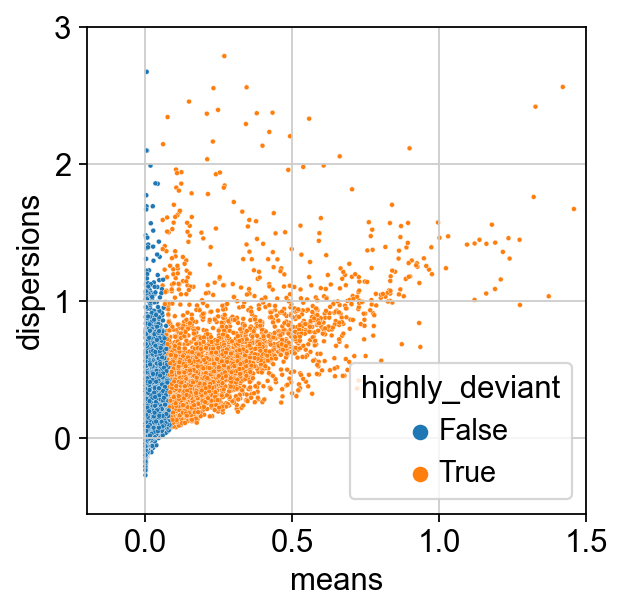

In [10]:
ax = sns.scatterplot(
    data=adata.var, x="means", y="dispersions", hue="highly_deviant", s=5
)
ax.set_xlim(None, 1.5)
ax.set_ylim(None, 3)
plt.show()

We observe that genes with a high mean expression are selected as highly deviant. This is in agreement with emprical observations by [Townes et al., 2019].

In [12]:
adata.write("s4d8_feature_selection.h5ad")
